In [1]:
import numpy as np
all_strings = np.load("/home/xw3763/project/data/smiles.npy")

In [5]:
import torch
d = torch.load(("/home/xw3763/project/data/smiles_3.0.pt"))

In [6]:
len(d)

456569

In [3]:
array = ["CCCCCC"] * 32
torch.save(array, "/home/xw3763/project/data/smiles_full_c_toyset.pt")

In [4]:
length_list = []
for i in range(len(d)):
    length_list.append(len(d[i]))

(array([  2.,   1.,   0.,   3.,   3.,   0.,   0.,   3.,   4.,   5.,   5.,
          7.,   4.,  17.,  25.,  16.,  31.,  22.,  13.,  32.,  58.,  67.,
         68.,  85.,  48., 108., 110., 141., 179., 181., 250., 141., 285.,
        344., 295., 229., 168.,  83., 122.,  72.,  58.,  42.,  51.,  30.,
         37.,  11.,   5.,   4.,   4.,   0.,   3.,   3.,   4.,   0.,   1.,
          0.,   0.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   1.,   1.,   5.,   2.,   5.,   0.,   0.,   1.,   4.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([  9.  ,  10.84,  12.68,  14.52,  16.36,  18.2 ,  20.04,  21.88,
         23.72,  25.56,  27.4 ,  29.24,  31.08,  32.92,  34.76,  36.6 ,
         38.44,  40.28,  42.12,  43.96,  45.8 ,  47.64,  49.48,  51.32,
         53.16,  55.  ,  56.84,  58.68,  60.52,  62.36,  64.2 ,  66.04,
         67.88,  69.72,  71.56

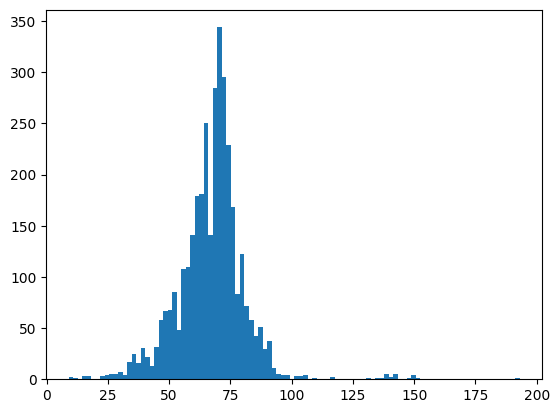

In [5]:
from matplotlib import pyplot as plt
plt.hist(length_list, bins=100)

In [7]:
from rdkit import Chem

def has_ring(smiles):
    """判断分子是否含有环
    参数:
        smiles (str): 分子SMILES字符串
    返回:
        int: 有环返回1，无环或无效分子返回0
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:  # 处理无效SMILES
        return 0
    
    # 获取环信息对象[1,6](@ref)
    ri = mol.GetRingInfo()
    
    # 判断是否存在环结构[1,7](@ref)
    return 1 if ri.NumRings() <= 2 else 0

In [3]:
from rdkit import Chem

def contains_cl_or_br(mol):
    """检查分子中是否含有氯或溴元素"""
    for atom in mol.GetAtoms():
        if atom.GetSymbol() in {'Cl', 'Br'}:
            return True
    return False

# 或者使用更简洁的写法：
def contains_cl_or_br(mol):
    return any(atom.GetSymbol() in {'Br'} for atom in mol.GetAtoms())

In [4]:
from  chemgfn.utils.rdkit_utils import sa_scorer

/home/xw3763/miniforge3/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterHierarchyMatcher> already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterCatalogEntry> already registered; second conversion method ignored.


In [8]:
from tqdm import tqdm

all_frags_no_ring = []
all_frags = []
new_smiles = []
for i in tqdm(range(0, 100000)):
    string = str(all_strings[i])
    mol = Chem.MolFromSmiles(string)
    try:
        sate = contains_cl_or_br(mol)
        new_smiles.append(string)
        if sate:
            if has_ring(string) == 0:
                if sa_scorer(mol) > 5.0:
                    all_frags_no_ring.append(string)
                    all_frags.append(string)
    except:
        continue

  0%|          | 0/100000 [00:00<?, ?it/s][16:40:26] SMILES Parse Error: syntax error while parsing: smiles
[16:40:26] SMILES Parse Error: check for mistakes around position 2:
[16:40:26] smiles
[16:40:26] ~^
[16:40:26] SMILES Parse Error: Failed parsing SMILES 'smiles' for input: 'smiles'
  2%|▏         | 1939/100000 [00:00<00:10, 9695.38it/s][16:40:26] SMILES Parse Error: syntax error while parsing: smiles
[16:40:26] SMILES Parse Error: check for mistakes around position 2:
[16:40:26] smiles
[16:40:26] ~^
[16:40:26] SMILES Parse Error: Failed parsing SMILES 'smiles' for input: 'smiles'
  6%|▌         | 5726/100000 [00:00<00:10, 9213.96it/s][16:40:27] SMILES Parse Error: syntax error while parsing: smiles
[16:40:27] SMILES Parse Error: check for mistakes around position 2:
[16:40:27] smiles
[16:40:27] ~^
[16:40:27] SMILES Parse Error: Failed parsing SMILES 'smiles' for input: 'smiles'
  8%|▊         | 7615/100000 [00:00<00:09, 9342.85it/s][16:40:27] SMILES Parse Error: syntax error wh

In [11]:
mol = Chem.MolFromSmiles(all_frags_no_ring[0])

In [13]:
Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)

'NCC12CC(Br)(CO1)C2'

In [14]:
from rdkit import Chem
import re

def validate_ring_markers(smiles):
    """
    验证不完整SMILES的环标记有效性，返回错误类型列表
    规则：
    1. 环标记必须成对出现（允许不完整SMILES存在未闭合标记）
    2. 数字必须从1开始连续递增
    3. 忽略方括号内数字（如[Fe+2]中的2）
    4. 允许多环标记（如C12）
    5. 正确处理%后的多位数（如%10）
    """
    errors = []
    
    # 预处理：移除方括号内容避免干扰
    cleaned_smiles = re.sub(r'$$.*?$$', '', smiles)
    
    # 提取所有环标记（含%处理）
    markers = re.findall(r'(?<!%)%?(\d+)', cleaned_smiles)
    markers = [int(m) for m in markers if m.isdigit()]
    
    # 规则1：检查数字连续性
    expected = 1
    seen = set()
    for m in markers:
        if m < expected:
            errors.append(f"重复标记 {m}")
        elif m > expected:
            errors.append(f"跳跃标记：预期 {expected} 但出现 {m}")
            expected = m + 1
        else:
            seen.add(m)
            expected = m + 1
    
    # 规则2：检查成对出现（允许单个标记存在）
    counter = {}
    current_num = None
    in_branch = 0  # 处理分支嵌套
    
    for i, char in enumerate(smiles):
        if char == '[': 
            # 跳过方括号内容
            end = smiles.find(']', i)
            if end != -1:
                i = end
            continue
                
        if char == '(': in_branch += 1
        if char == ')': in_branch -= 1
        
        # 捕获环标记（含%处理）
        if char == '%':
            if i+1 < len(smiles) and smiles[i+1].isdigit():
                num_str = ''
                j = i+1
                while j < len(smiles) and smiles[j].isdigit():
                    num_str += smiles[j]
                    j += 1
                current_num = int(num_str)
        elif char.isdigit() and (i == 0 or smiles[i-1] != '%'):
            current_num = int(char)
        
        if current_num is not None:
            # 分支内标记需特殊处理
            if in_branch > 0:
                key = (current_num, 'branch')
            else:
                key = current_num
                
            if key in counter:
                counter[key] += 1
                if counter[key] > 2:
                    errors.append(f"标记 {current_num} 重复超过两次")
            else:
                counter[key] = 1
            
            current_num = None
    
    # 验证成对性（允许单个存在）
    for num, count in counter.items():
        if isinstance(num, tuple):  # 分支内标记
            if count % 2 != 0:
                errors.append(f"分支内标记 {num[0]} 未闭合")
        else:
            if count > 2:
                errors.append(f"主链标记 {num} 重复超过两次")
    
    return errors if errors else ["环标记有效"]

# 测试案例
test_cases = [
    ("C1CC", []),  # 有效不完整
    ("C12C3C1C23", []),  # 有效多环
    ("C2CC", ["跳跃标记：预期 1 但出现 2"]), 
    ("C1C%10CC1", []),  # 正确处理%标记
    ("[O-]C1CC1", []),  # 忽略方括号内数字
    ("C1(C2CC)CC2", ["分支内标记 2 未闭合"])
]

for smi, expected in test_cases:
    result = validate_ring_markers(smi)
    print(f"测试 {smi}:")
    print("预期:", expected)
    print("结果:", result)
    print("-"*40)

测试 C1CC:
预期: []
结果: ['环标记有效']
----------------------------------------
测试 C12C3C1C23:
预期: []
结果: ['跳跃标记：预期 1 但出现 12', '重复标记 3', '重复标记 1', '跳跃标记：预期 13 但出现 23']
----------------------------------------
测试 C2CC:
预期: ['跳跃标记：预期 1 但出现 2']
结果: ['跳跃标记：预期 1 但出现 2']
----------------------------------------
测试 C1C%10CC1:
预期: []
结果: ['跳跃标记：预期 2 但出现 10', '重复标记 1']
----------------------------------------
测试 [O-]C1CC1:
预期: []
结果: ['重复标记 1']
----------------------------------------
测试 C1(C2CC)CC2:
预期: ['分支内标记 2 未闭合']
结果: ['重复标记 2', '分支内标记 2 未闭合']
----------------------------------------
